# Проект спринта 10. Прогнозирование массы морских черепах по результатам внешних измерений.

## Цель и задачи  

**Цель:** Разработка механизма определения массы морских черепах по результатам измерений, полученным из системы компьютерного зрения.   

**Задачи:**
1. Загрузка данных и знакомство с их содержимым.
2. Исследовательский анализ данных.
3. Предобработка данных для машинного обучения.
4. Разработка механизма предсказания массы черепах.
    - Обучение нескольких моделей линейной регрессии с разными параметрами.
    - Сравнение моделей по метрикам на валидационной выборке.
    - Проверка лучшей модели на тестовой выборке.
    - Разработка функции прогнозирования массы черепахи по заданным параметрам.
5. Формулировка выводов и рекомендаций по использованию модели.

## Данные

Для анализа поступили данные в формате CSV-файла, который доступен по ссылке [turtles.csv](https://code.s3.yandex.net/datasets/turtles.csv).
Данные содержат следующие поля:

- `id` — идентификатор измерения.
- `binomial_name` — международное научное название вида черепахи.
- `registration_number` — регистрационный номер черепахи.
- `shell_length` — длина панциря, мм.
- `shell_width` — ширина панциря, мм.
- `head_length` — длина головы, мм.
- `head_width` — ширина головы, мм.
- `flipper_length_n` — длина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо `n` указан номер от `1` до `4`.
- `flipper_width_n` — ширина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо `n` указан номер от `1` до `4`.
- `circle_count` — количество колец роста на панцире черепахи.
- `measure_count` — количество измерений, которые произвели, прежде чем усреднить показатели черепахи и добавить их в таблицу.
- `shell_crack` — наличие трещин панциря.
- `timestamp` — время внесения данных о черепахе.
- `weight` — масса черепахи, кг.

## Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

## 1. Загрузка данных и знакомство с ними

- Устанавливаем зависимости и импортируем необходимые библиотеки:

In [1]:
%pip install -q scikit-learn
%pip install -q --upgrade seaborn
%pip install -q --upgrade jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import math

import pandas as pd
import numpy as np

# Библиотеки машинного обучения
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import OneHotEncoder

# Библиотеки для построения графиков
import seaborn as sns
import matplotlib.pyplot as plt

# Для форматирования в HTML
from IPython.display import display, HTML, Markdown

- Загрузим данные и выведем сведения о них:

In [3]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/turtles.csv', sep='\t')

print(df.info())
display(df.head())

initial_count = len(df)

<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   str    
 2   registration number  8832 non-null   str    
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   int64  
 16 

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,"3,0",NaN,1703159226,"87,687"
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,"1,0",1.0,1689428175,"26,949"
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,"3,0",NaN,1745783111,"30,016"
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,"4,0",1.0,1677757151,"33,917"
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,"4,0",1.0,1744455613,"28,511"


- Доля пропусков в столбцах в процентах:

In [4]:
display(round(df.isna().sum() / initial_count * 100, 2))

df_without_meas_misses = df.dropna(subset=['shell_length',
                                           'head_length',
                                           'head_width',
                                           'flipper_length_3',
                                           'flipper_width_3',
                                           'flipper_length_4',
                                           'flipper_width_4',
                                           'weight'])

meas_misses_count = initial_count - len(df_without_meas_misses)

print(f"Количество строк с пропусками в измерениях: {meas_misses_count} ({meas_misses_count / initial_count * 100:.2f})%")
print("Значения в поле shell_crack: ", df['shell_crack'].unique())

id                      0.00
binomial_name           0.55
registration number     0.33
shell_length            0.98
shell_width             0.00
head_length             1.65
head_width              1.65
flipper_length_1        0.00
flipper_width_1         0.00
flipper_length_2        0.00
flipper_width_2         0.00
flipper_length_3        1.14
flipper_width_3         1.14
flipper_length_4        1.14
flipper_width_4         1.14
circle_count            0.00
measure_count           2.98
shell_crack            75.44
timestamp               0.00
weight                  0.21
dtype: float64

Количество строк с пропусками в измерениях: 346 (3.90)%
Значения в поле shell_crack:  [nan  1.  5.  4.  3.  2.]


Выводы:
- В 346 строках (3.9%) отсутствуют такие важные для обучения модели признаки, как вес, длина панциря, длина и ширина головы, а также задних плавников. Вероятно, отсутствие этих данных связано с тем, что черепаха в течение всех измерений занимала неподходящее для вычисления этих параметров положение относительно камеры. Эти данные можно удалить. Вес является целевой переменной для прогноза, поэтому строки с пропуском в этом поле однозначно подлежат удалению.
- Столбец с длиной панциря `shell_length` имеет тип `float64`, тогда как столбец с шириной панциря `shell_width` - `int64`. Это связано с пропусками в поле `shell_length`. После обработки пропусков тип можно будет преобразовать к `int`.
- Столбцы `head_length`, `head_width`, `flipper_length_3`, `flipper_widgth_3`, `flipper_length_4`, `flipper_widgth_4` по причине наличия пропусков также имеют тип `float64`. После обработки пропусков тип можно будет преобразовать к `int`.
- Столбцы `measure_count` и `weight` из-за неправильного разделителя целой и дробной части (запятая) получили тип `str`. Необходимо заменить разделитель на точку и преобразовать тип к `int` и `float` соответственно. Пропуски в `measure_count` можно заменить на нули, так как этот параметр не является характеристикой черепахи и не будет использоваться в качестве признака при обучении модели.
- Столбец `shell_crack` имеет тип `float64`. Пропуски в значениях, очевидно, соответствуют отсутствию трещин, а непустые значения - их количеству. Пропуски можно заменить на нули, а тип столбца - преобразовать к `int`.
- Столбцы `binomial_name` и `registration number` являются строковыми и не будут непосредственно использоваться в обучении модели, поэтому пропуски в них можно заполнить индикатором `undefined`.
- Имя столбца `registration number` следует преобразовать к snake case.
- Столбец `timestamp` содержит время в формате UNIX, можно преобразовать его в `datetime`

## 2. Предобработка данных.

### 2.1. Обработка пропусков и дубликатов
- Определим функции, которые будут использоваться для построения диаграмм:

In [5]:
# Функция для построения скаттерплота
def draw_scatterplot(data, 
                     title, 
                     x, 
                     y, 
                     hue,
                     xlabel, 
                     ylabel,
                     figsize=(12, 6)):
    plt.figure(figsize=figsize)
    sns.scatterplot(data=data, 
                    x=x,
                    y=y,
                    hue=hue)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

# Функция для построения джойнтплота
def draw_jointplot(data, 
                   title, 
                   x, 
                   y, 
                   hue, 
                   xlabel, 
                   ylabel, 
                   figsize=(12, 6)):
    g = sns.jointplot(data=data, 
                    x=x,
                    y=y,
                    hue=hue,
                    marginal_kws={"common_norm": False})
    
    g.set_axis_labels(xlabel, ylabel)
    g.fig.set_size_inches(*figsize)
    g.fig.suptitle(title, fontsize=14)
    g.fig.tight_layout()
    g.fig.subplots_adjust(top=0.92)
    plt.show()
    plt.close(g.fig)

# Функция для построения боксплота
def draw_boxplot(data, 
                 title, 
                 hue, 
                 xlabel, 
                 ylabel, 
                 figsize=(12, 6)):
    plt.figure(figsize=figsize)
    sns.boxplot(data=data,
            showmeans=True,
            legend=False,
            meanprops={
                "marker": "o",
                "markerfacecolor": "white",
                "markeredgecolor": "black",
                "markersize": 8
            },
            orient='h',
            hue=hue)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Функция для построения гистограммы
def draw_kdeplot(data,
                   title,
                   xlabel, 
                   ylabel, 
                   figsize=(12, 4),
                   **kwargs):
    plt.figure(figsize=figsize)
    sns.kdeplot(data=data,
                 **kwargs)

    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Функция для построения столбчатой диаграммы
def draw_barplot(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None):
    series.head(10).plot(
        title=title,
        kind='bar' if vertical else 'barh',
        figsize=(8, 4) if vertical else (12, 4),
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot)
    
    if mean != None:
        if vertical:
            plt.axhline(mean, color='red', linestyle='--')
        else:
            plt.axvline(mean, color='red', linestyle='--')
    plt.show()

def draw_heatmap(df, title):
    plt.figure(figsize=(12,1))
    plt.title(title)
    sns.heatmap(data=df, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()    

- Обработаем строки с пропусками и преобразуем типы данных столбцов датасета:

In [6]:
# Удаляем пропуски в измерениях параметров черепахи
df = df_without_meas_misses

# Подготовка к преобразованию типов к int и float
df['measure_count'] = df['measure_count'].str.replace(',', '.')
df['weight'] = df['weight'].str.replace(',', '.')
df.fillna({'shell_crack': 0, 'measure_count': '0'}, inplace=True)

int_cols = ['shell_length',
                 'shell_width',
                 'head_length',
                 'head_width',
                 'flipper_length_1',
                 'flipper_width_1',
                 'flipper_length_2',
                 'flipper_width_2',
                 'flipper_length_3',
                 'flipper_width_3',
                 'flipper_length_4',
                 'flipper_width_4',
                 'circle_count',
                 'measure_count',
                 'shell_crack']

# Преобразуем типы целочисленных столбцов
df[int_cols] = df[int_cols].apply(pd.to_numeric, downcast='integer')

# Преобразуем тип столбца weight
df['weight'] = pd.to_numeric(df['weight'], downcast='float')
# Переименуем столбец
df.rename(columns={'registration number': 'registration_number'}, inplace=True)
# Заполним пропуски в строковых столбцах
df.fillna({'binomial_name': 'undefined',
           'registration_number': 'undefined'}, inplace=True)
# Преобразуем столбец timestamp к типу datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

df.info()
display(df.head())

last_count = len(df)
meas_misses_count = initial_count - last_count
print(f"Удалено {meas_misses_count} строк.")

<class 'pandas.DataFrame'>
Index: 8515 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype        
---  ------               --------------  -----        
 0   id                   8515 non-null   int64        
 1   binomial_name        8515 non-null   str          
 2   registration_number  8515 non-null   str          
 3   shell_length         8515 non-null   int16        
 4   shell_width          8515 non-null   int16        
 5   head_length          8515 non-null   int16        
 6   head_width           8515 non-null   int16        
 7   flipper_length_1     8515 non-null   int16        
 8   flipper_width_1      8515 non-null   int16        
 9   flipper_length_2     8515 non-null   int16        
 10  flipper_width_2      8515 non-null   int16        
 11  flipper_length_3     8515 non-null   int16        
 12  flipper_width_3      8515 non-null   int16        
 13  flipper_length_4     8515 non-null   int16        
 14  flipper_

,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700,381,112,82,356,205,331,185,270,180,273,144,63,3,0,2023-12-21 11:47:06,87.686996
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341,295,65,48,216,190,229,186,164,182,180,149,0,1,1,2023-07-15 13:36:15,26.948999
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408,343,71,70,308,224,285,232,264,179,268,176,0,3,0,2025-04-27 19:45:11,30.016001
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408,307,50,54,280,168,269,218,199,165,209,180,0,4,1,2025-04-12 11:00:13,28.511000
5,25045,Lepidochelys olivacea,1b076bdf8f9ed92f370f64ffd28b7dd6,341,254,54,55,250,204,240,217,197,152,185,154,0,1,0,2025-06-08 07:01:20,27.513000


Удалено 346 строк.


- Проверим датасет на дубликаты и удалим их с исключением столбца `id` и приведением столбца `binomial_name` к нижнему регистру:

In [7]:
df['binomial_name'] = df['binomial_name'].str.lower()
dup_columns = df.columns.to_list()
dup_columns.remove('id')

dup_count = df.duplicated(subset=dup_columns).sum()
df = df.drop_duplicates(subset=dup_columns)

print(f"Количество удаленных дубликатов: {dup_count}.")
last_count = len(df)
print(f"Суммарное количество удаленных строк: {initial_count - last_count} ({(initial_count - last_count) / initial_count * 100:.2f})%")

Количество удаленных дубликатов: 988.
Суммарное количество удаленных строк: 1334 (15.05)%


На данном этапе предобработки были удалены 346 строк с пропусками в измерениях и 988 дубликатов. Датасет сократился на 1334 строки (или 15.05%).

### 2.2. Исследование категориальных и временных значений.

В приведенном датасете только один категориальный столбец - название вида черепахи `binomial_name`. Выведем все категории:

In [8]:
display(pd.Series(df['binomial_name'].unique()).sort_values())

0           caretta caretta
2            chelonia mydas
4      dermochelys coriacea
3    eretmochelys imbricata
6       lepidochelys kempii
1     lepidochelys olivacea
5                 undefined
dtype: str

- Отобразим количество измерений в каждой категории на столбчатой диаграмме:

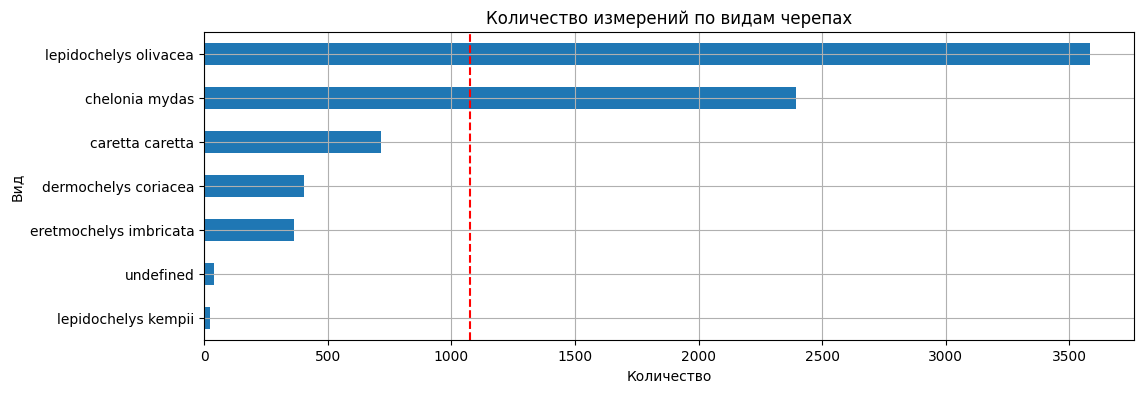

,0
binomial_name,
lepidochelys olivacea,3582
chelonia mydas,2396
caretta caretta,715
dermochelys coriacea,406
eretmochelys imbricata,363
undefined,42
lepidochelys kempii,23


In [9]:
s_groups = df.groupby('binomial_name').size()
draw_barplot(s_groups.sort_values(),
             "Количество измерений по видам черепах",
             "Вид",
             "Количество",
             vertical=False,
             mean=s_groups.mean())

display(s_groups.sort_values(ascending=False).to_frame().style.background_gradient(cmap='viridis'))

- Проверим данные о времени наблюдений:

In [10]:
print(f"Даты наблюдений с {df['timestamp'].min()} по {df['timestamp'].max()}.")

Даты наблюдений с 2023-01-01 10:47:51 по 2025-07-04 05:39:19.


**Выводы:**
- Распределение количества особей по видам в датасете выглядит правдоподобно: оно примерно пропорционально численности этих видов в дикой природе.
- Данные о времени наблюдений корректны.
- На этапе подготовки тренировочной, тестовой и валидационной выборок для обучения моделей, необходимо проконтролировать, чтобы виды были в них представлены пропорционально.
- Небольшое количество категориальных значений позволяет использовать метод one-hot для их кодирования. 

### 2.3. Исследование числовых значений.

- Статистики по числовым параметрам:

In [11]:
def show_numeric_stat():
    display(df[int_cols].describe(percentiles=[0.25, 0.50, 0.75, 0.80, 0.90, 0.95, 0.99, 0.995]))
    print("Статистики для веса:")
    display(df['weight'].describe(percentiles=[0.25, 0.50, 0.75, 0.80, 0.90, 0.95, 0.99, 0.995]))

show_numeric_stat()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack
count,7527.000000,7527.000000,7527.000000,7527.000000,7527.000000,7527.000000,7527.00000,7527.000000,7527.000000,7527.000000,7527.000000,7527.000000,7527.000000,7527.000000,7527.000000
mean,760.824366,596.271423,122.893982,115.382357,496.254285,379.834463,496.82038,380.070015,396.859306,303.926398,396.945397,304.401355,41.022585,2.402949,0.409194
std,620.194861,471.187929,67.435401,61.970516,352.724321,213.596226,353.88463,213.122262,282.518507,170.986531,281.489179,171.168050,36.896336,1.181218,0.908934
min,132.000000,79.000000,19.000000,12.000000,60.000000,34.000000,57.00000,35.000000,50.000000,27.000000,44.000000,25.000000,0.000000,0.000000,0.000000
25%,440.000000,341.000000,73.000000,67.000000,295.000000,228.000000,295.00000,229.000000,239.000000,182.000000,236.000000,183.000000,0.000000,1.000000,0.000000
50%,637.000000,487.000000,105.000000,98.000000,417.000000,332.000000,417.00000,330.000000,332.000000,264.000000,333.000000,266.000000,35.000000,2.000000,0.000000
75%,951.000000,793.500000,158.000000,156.000000,571.000000,493.000000,572.00000,498.000000,457.000000,396.000000,456.500000,396.000000,73.000000,3.000000,0.000000
80%,1045.000000,863.000000,173.000000,170.000000,620.000000,544.000000,618.00000,548.000000,492.000000,436.000000,495.000000,436.000000,79.000000,4.000000,1.000000
90%,1288.000000,1039.000000,214.400000,207.000000,779.000000,675.000000,767.00000,675.000000,617.400000,541.000000,619.000000,542.000000,91.000000,4.000000,1.000000
95%,1481.400000,1170.000000,250.000000,234.000000,1227.100000,783.000000,1239.40000,779.000000,977.100000,622.000000,997.000000,628.000000,101.000000,4.000000,2.000000


Статистики для веса:


count    7527.000000
mean       78.645294
std        95.319244
min         0.000000
25%        31.111500
50%        41.105999
75%        84.829002
80%        98.729799
90%       145.179599
95%       365.394012
99%       502.426140
99.5%     534.758814
max       617.776978
Name: weight, dtype: float64

- Построим боксплоты для распределения измерений:

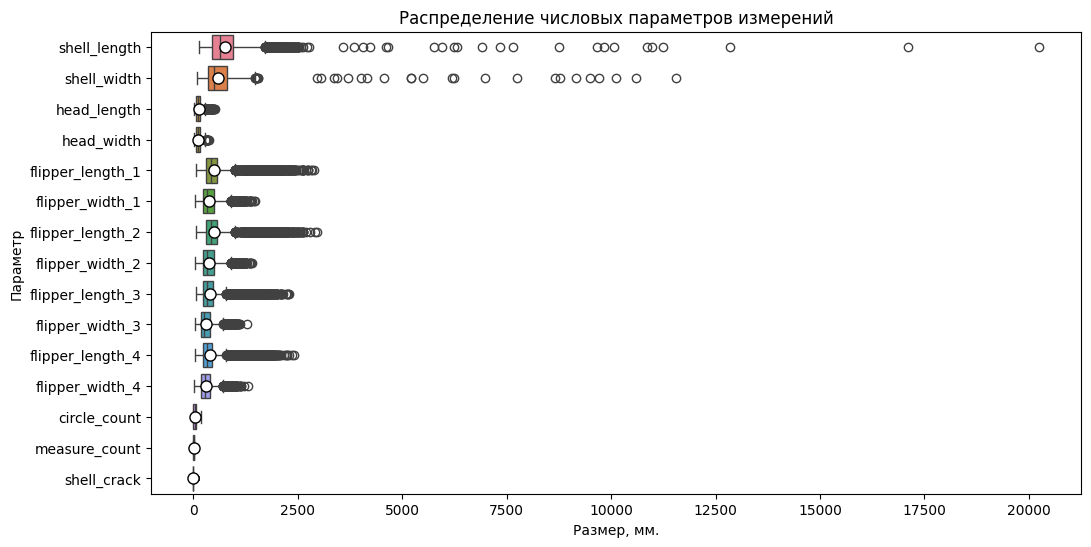

In [12]:
draw_boxplot(df[int_cols],
             "Распределение числовых параметров измерений",
             None,
             "Размер, мм.",
             "Параметр")

- В столбцах `shell_length` и `shell_width` присутствуют выбросы до 20000 мм. Очевидно, это ошибка, о которой говорилось в сообщении заказчика (значения умножены на 10). Необходимо выяснить, какие из значений нуждаются в коррекции.
- Присутствуют записи с нулевым весом. Их необходимо удалить, так как они некорректны и будут искажать обучение.
- Остальные числовые значения находятся в допустимых пределах (например, у кожистых черепах `dermochelys coriacea` размер ласт может достигать 2.7-2.9 м.)

Удалим записи с нулевыми весами и построим скаттерплот зависимости веса от длины и ширины панциря, чтобы определить искаженные измерения:

Удалено 8 строк.
Новое количество строк: 7519


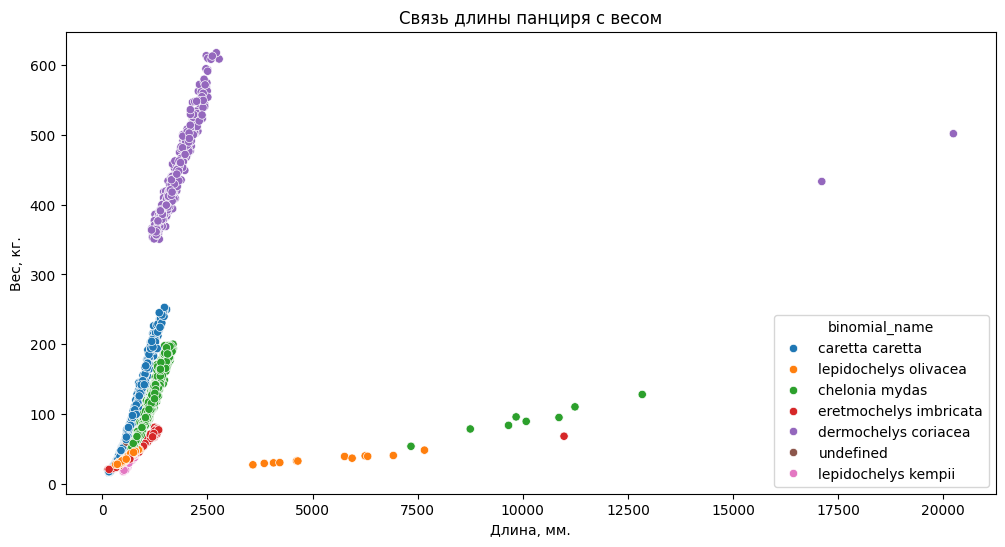

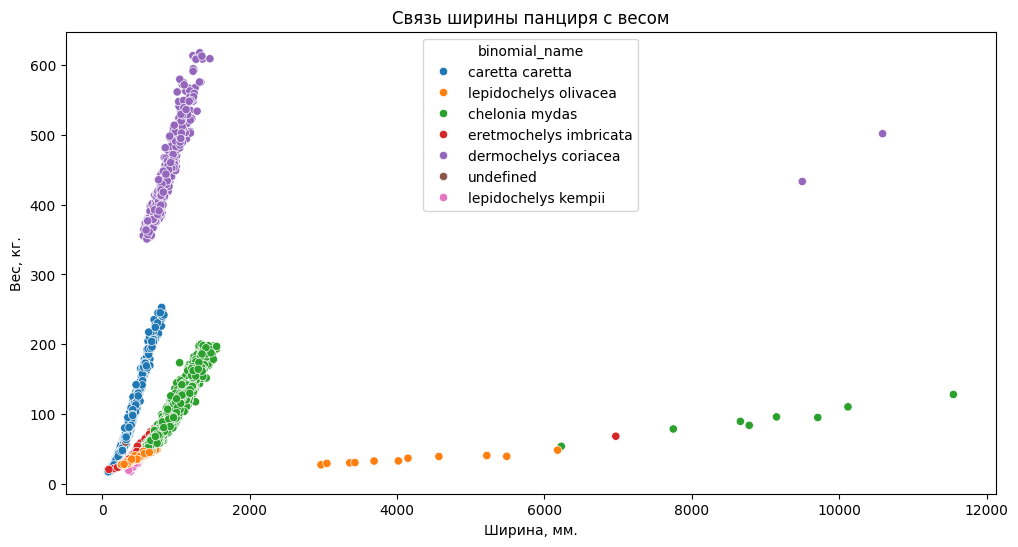

In [13]:
# Удалим записи с весом 0
df = df[df['weight'] > 0]
print(f"Удалено {last_count - len(df)} строк.")
print(f"Новое количество строк: {len(df)}")

draw_scatterplot(df, 
                 "Связь длины панциря с весом",
                'shell_length',
                'weight',
                'binomial_name',
                "Длина, мм.",
                "Вес, кг.")

draw_scatterplot(df, 
                 "Связь ширины панциря с весом",
                'shell_width',
                'weight',
                'binomial_name',
                "Ширина, мм.",
                "Вес, кг.")

На диаграмме видно, что в коррекции нуждаются значения длины более 3000 и ширины более 2500. Скорректируем их путем деления на 10:

In [14]:
df.loc[df['shell_length'] > 3000, 'shell_length'] /= 10
df.loc[df['shell_width'] > 2500, 'shell_width'] /= 10

- Обновленные диаграммы распределения и статистики по числовым параметрам:

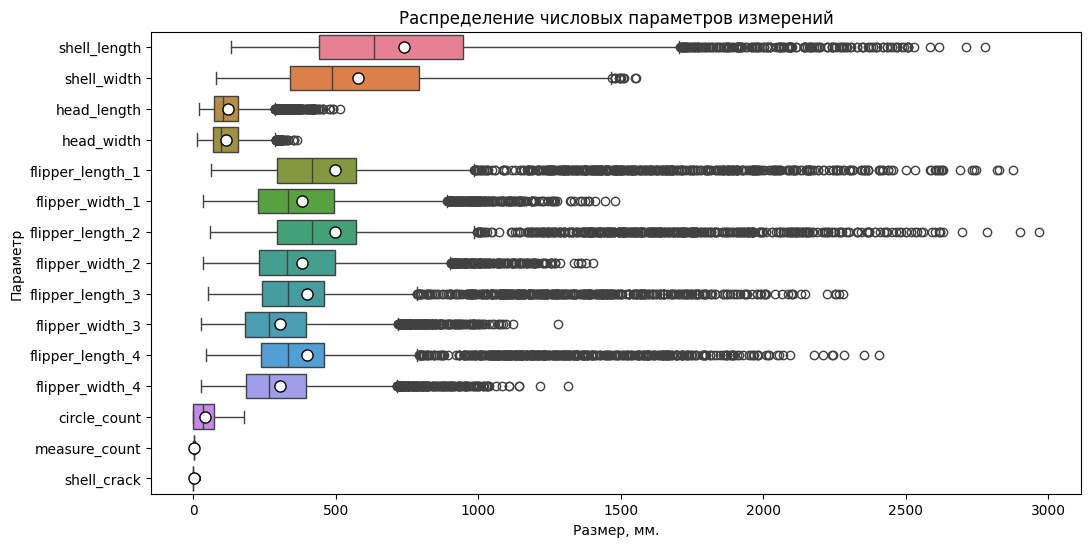

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack
count,7519.000000,7519.000000,7519.000000,7519.000000,7519.000000,7519.000000,7519.000000,7519.000000,7519.000000,7519.000000,7519.000000,7519.000000,7519.000000,7519.000000,7519.000000
mean,737.727357,578.205878,122.888150,115.365341,496.227158,379.799175,496.801968,380.031919,396.851310,303.895598,396.949461,304.371592,41.006916,2.402580,0.409629
std,392.977324,303.582620,67.447863,61.972240,352.849465,213.638557,354.026593,213.169361,282.633517,171.000237,281.616667,171.184776,36.898824,1.181258,0.909319
min,132.000000,79.000000,19.000000,12.000000,60.000000,34.000000,57.000000,35.000000,50.000000,27.000000,44.000000,25.000000,0.000000,0.000000,0.000000
25%,440.000000,340.000000,73.000000,67.000000,295.000000,228.000000,295.000000,229.000000,239.000000,182.000000,236.000000,183.000000,0.000000,1.000000,0.000000
50%,635.000000,487.000000,105.000000,98.000000,417.000000,332.000000,417.000000,330.000000,332.000000,264.000000,333.000000,266.000000,35.000000,2.000000,0.000000
75%,947.500000,790.500000,158.000000,156.000000,571.000000,493.000000,572.000000,498.000000,457.000000,396.000000,456.500000,396.000000,73.000000,3.000000,0.000000
80%,1038.000000,857.400000,173.000000,170.000000,620.000000,544.400000,618.000000,548.000000,492.000000,436.000000,495.000000,436.000000,79.000000,4.000000,1.000000
90%,1281.200000,1034.000000,214.200000,207.000000,779.000000,675.000000,767.000000,675.000000,617.200000,541.000000,619.200000,542.000000,91.000000,4.000000,1.000000
95%,1469.000000,1158.000000,250.000000,234.000000,1228.700000,783.100000,1240.300000,779.100000,978.100000,622.000000,1000.400000,628.000000,101.000000,4.000000,2.000000


Статистики для веса:


count    7519.000000
mean       78.728973
std        95.335388
min        15.731000
25%        31.131499
50%        41.139999
75%        84.836998
80%        98.774400
90%       145.276196
95%       365.647412
99%       502.499018
99.5%     534.788094
max       617.776978
Name: weight, dtype: float64

In [15]:
draw_boxplot(df[int_cols],
             "Распределение числовых параметров измерений",
             None,
             "Размер, мм.",
             "Параметр")
show_numeric_stat()

- Построим диаграммы плотности распределения числовых параметров:

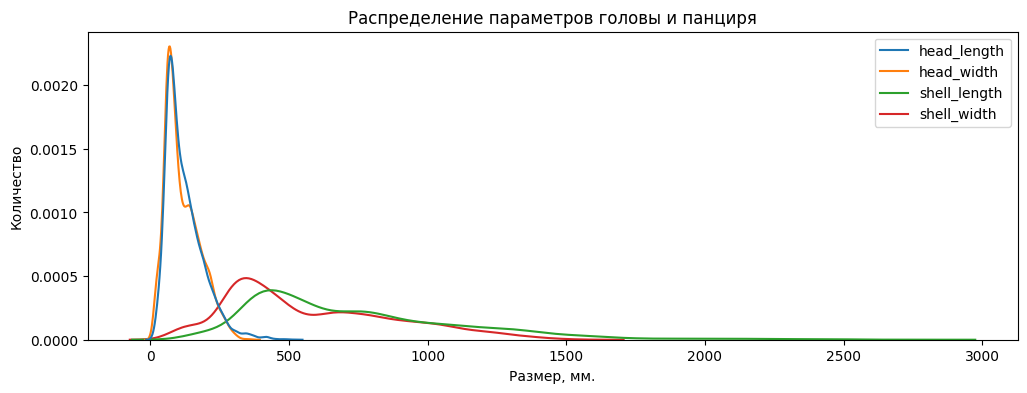

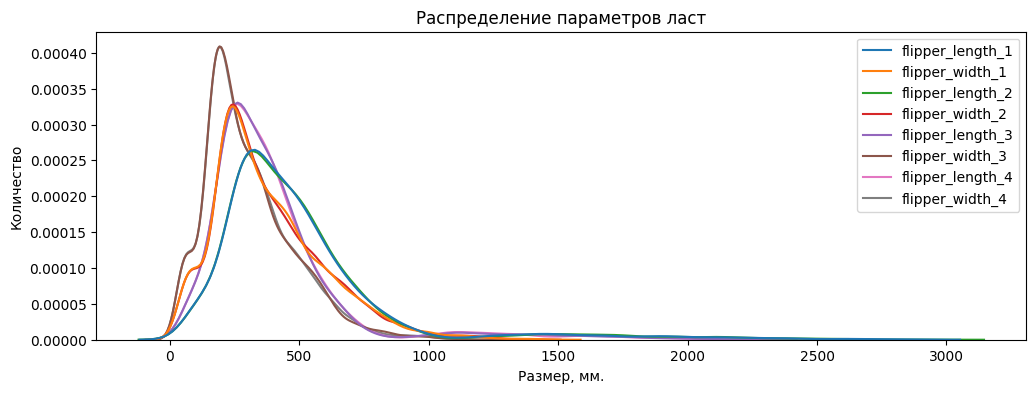

In [16]:
draw_kdeplot(df[['head_length', 'head_width', 'shell_length', 'shell_width']],
               "Распределение параметров головы и панциря",
               "Размер, мм.",
               "Количество")

draw_kdeplot(df[['flipper_length_1',
                   'flipper_width_1',
                   'flipper_length_2',
                   'flipper_width_2',
                   'flipper_length_3',
                   'flipper_width_3',
                   'flipper_length_4',
                   'flipper_width_4']],
               "Распределение параметров ласт",
               "Размер, мм.",
               "Количество")

Параметры измерений после коррекции выглядят правдоподобно: распределения длины и ширины передних и задних ласт практически совпадают попарно; длина панциря в среднем меньше ширины.
Вместе с тем видно наличие выбросов в большую сторону по всем измерениям, из-за которых диаграммы плотности имеют тяжелые правые хвосты, а среднее смещено в большую сторону от медианы.
<br>
Вероятно, наличие выбросов связано с природными отличиями между разными видами черепах: измерения для большей части видов находятся в одном диапазоне, а отдельные виды имеют нехарактерно большие размеры и вес, которые на общей диаграмме попадают в выбросы. Для проверки этой гипотезы построим совместные диаграммы распределения веса и остальных числовых параметров:

- Построим диаграммы связи числовых параметров с весом:

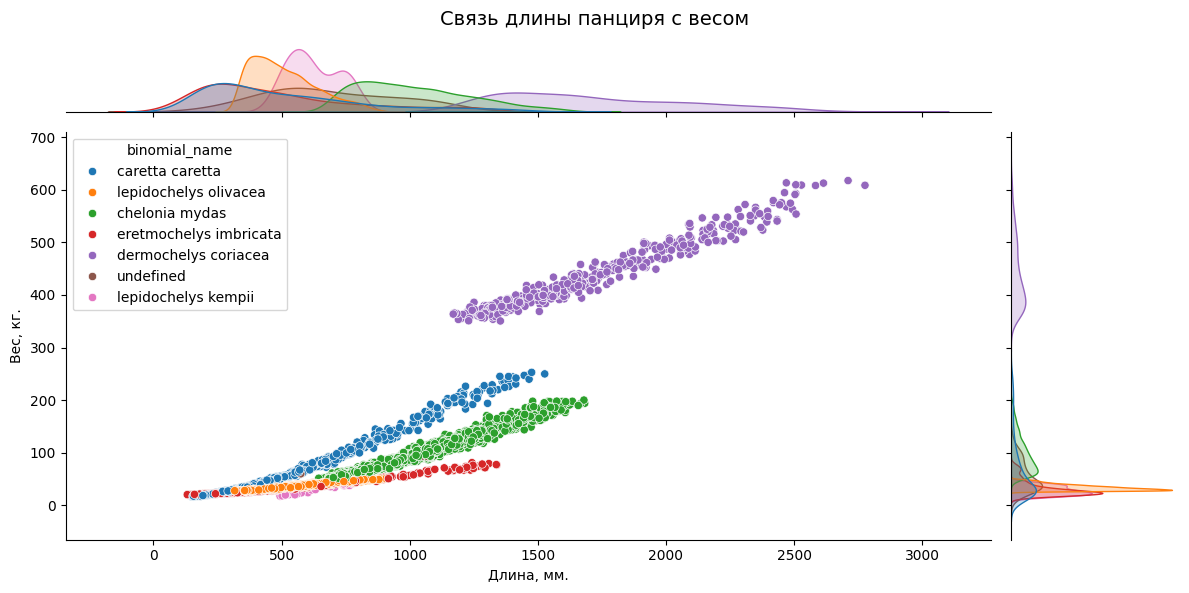

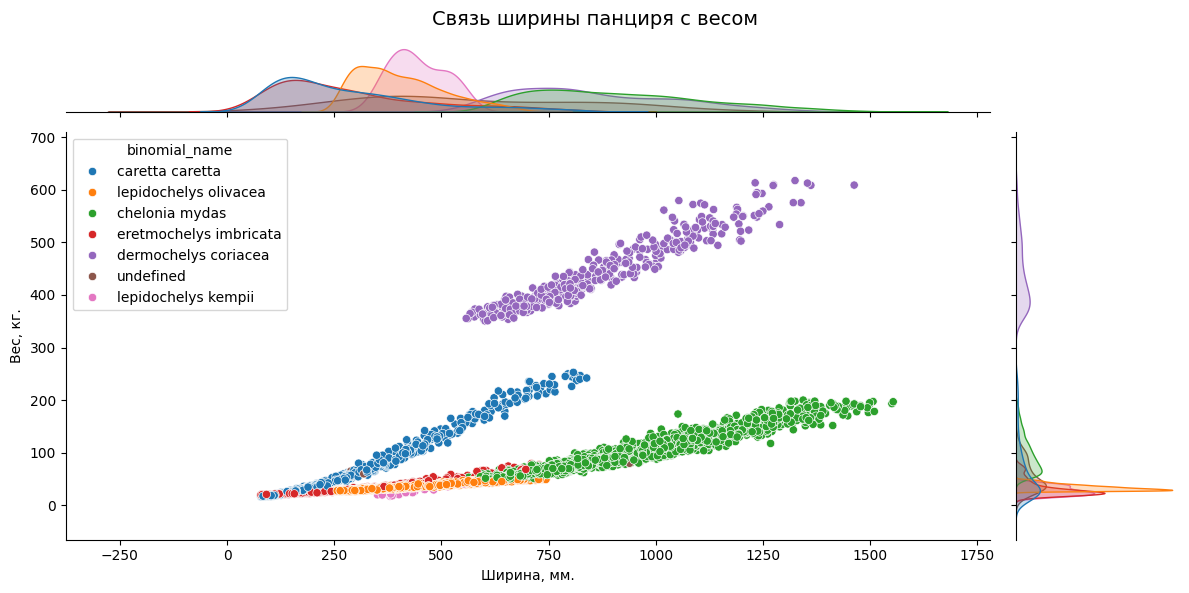

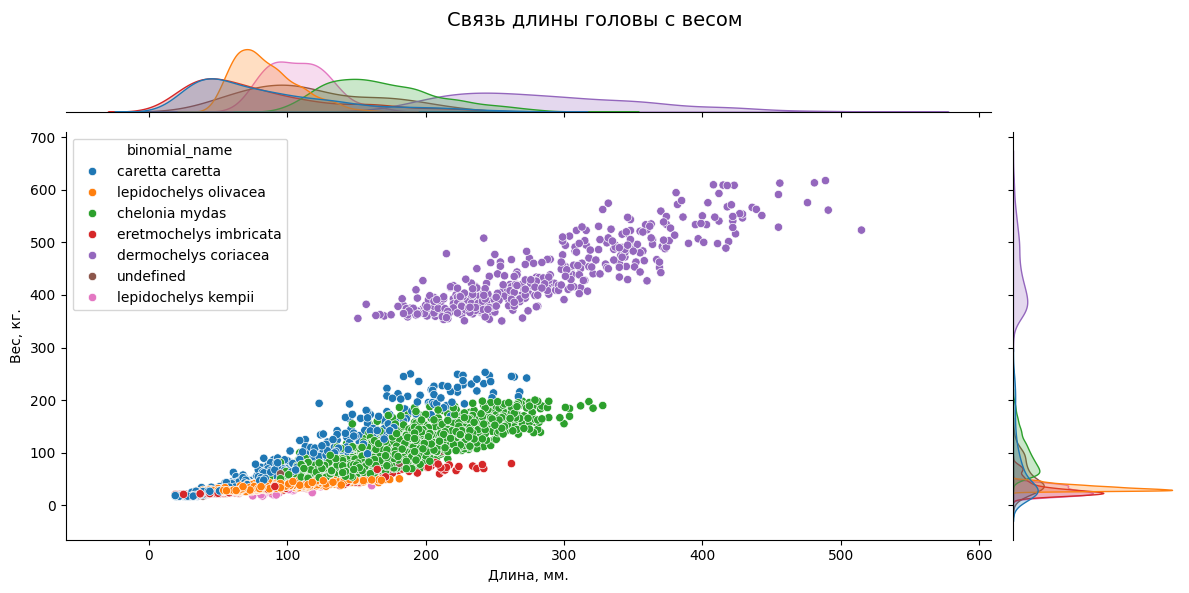

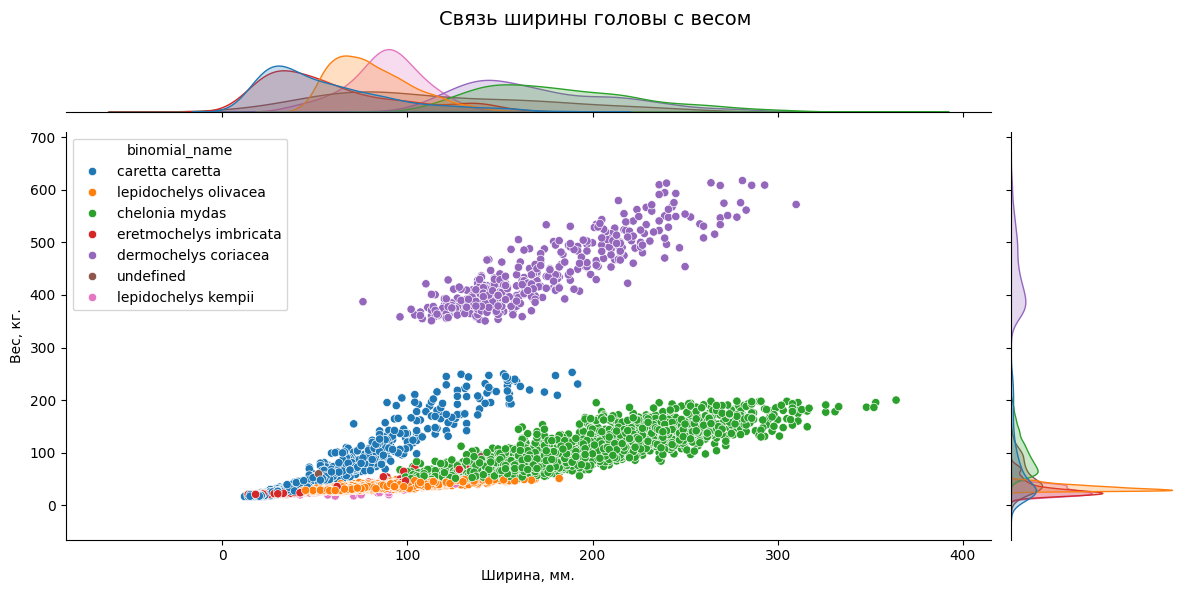

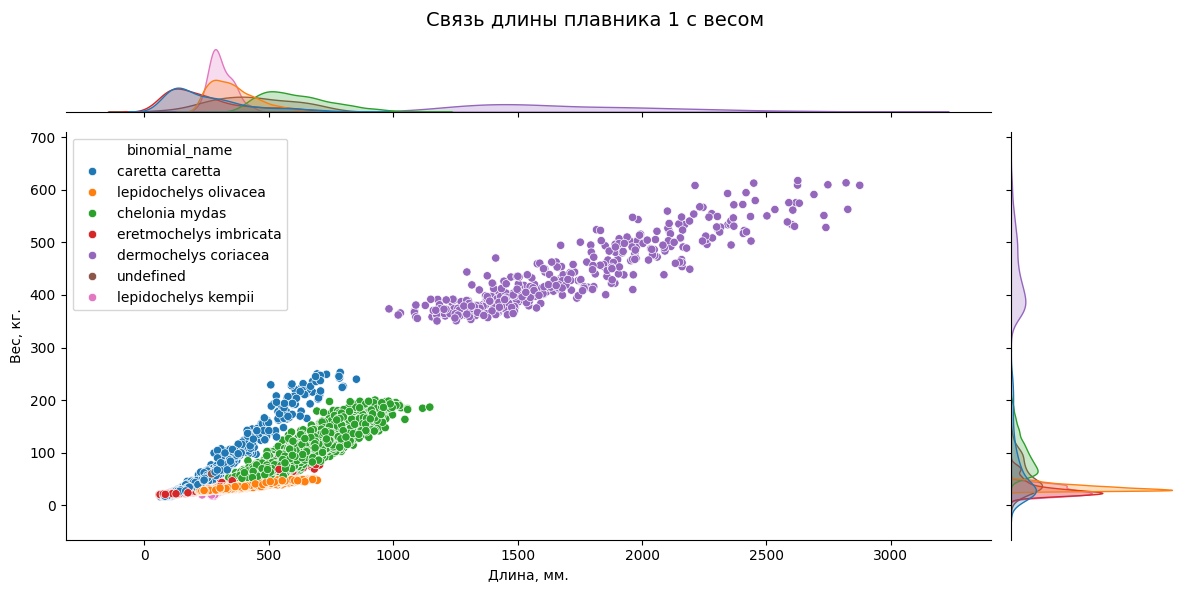

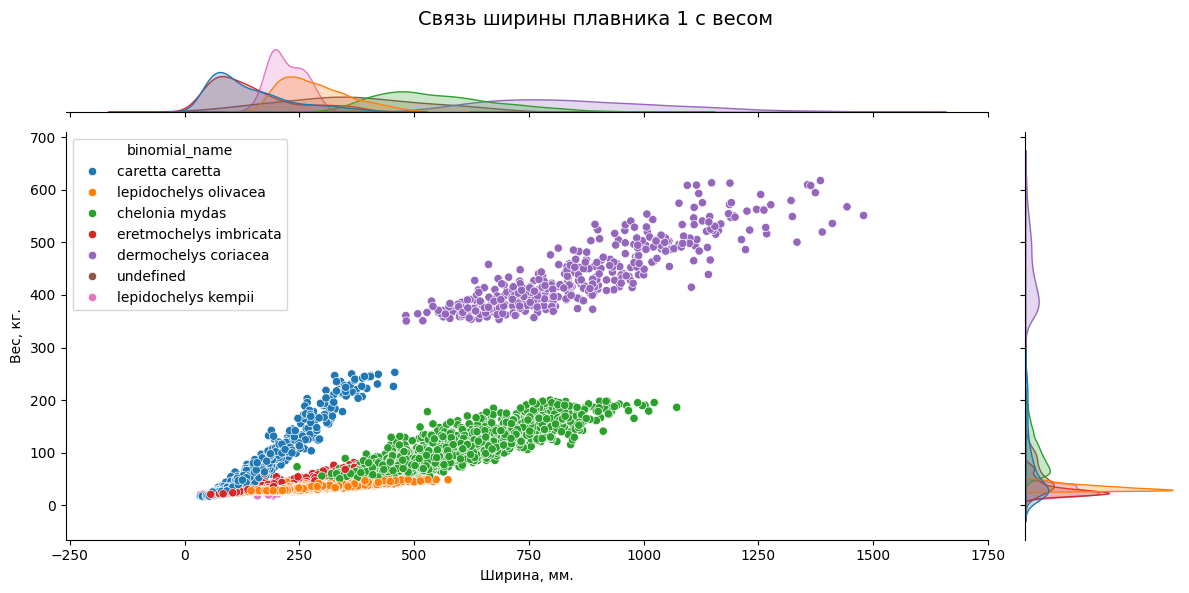

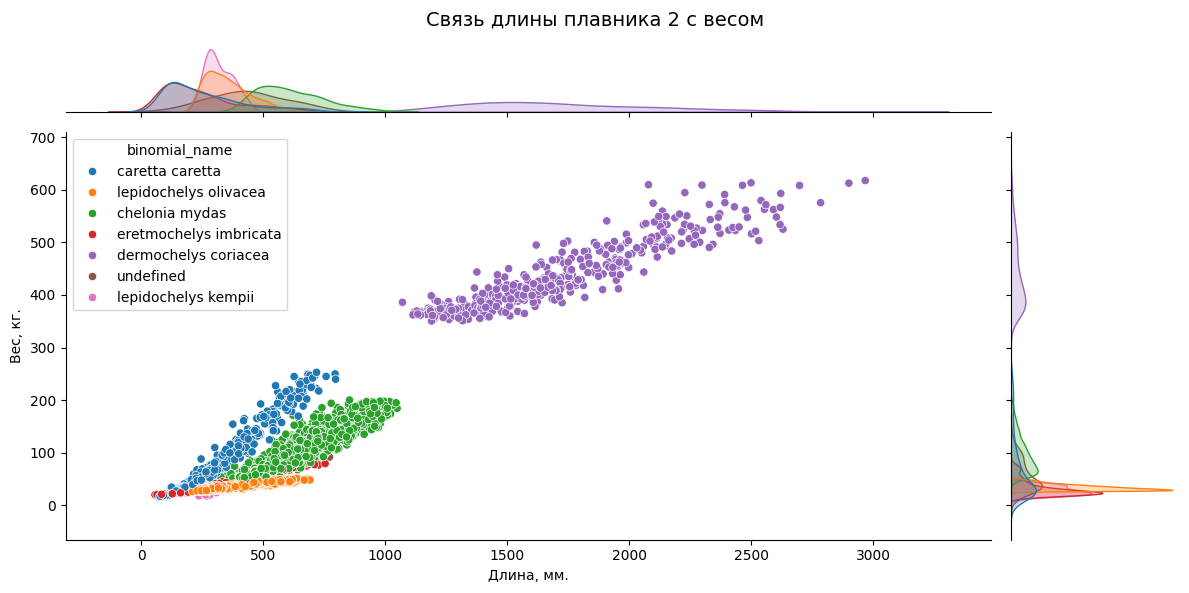

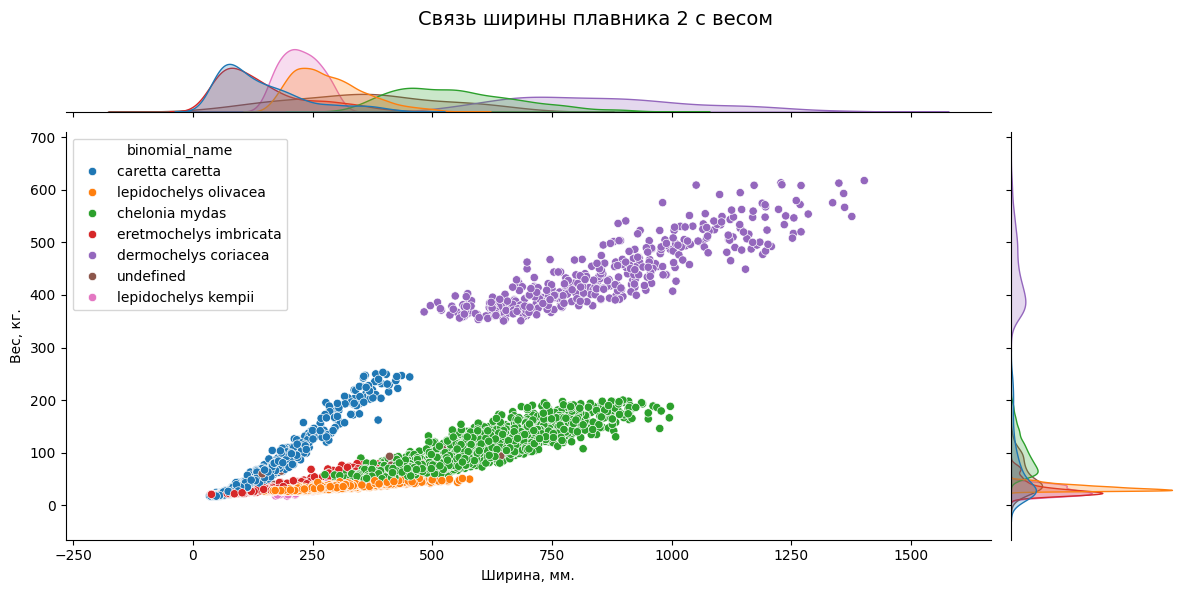

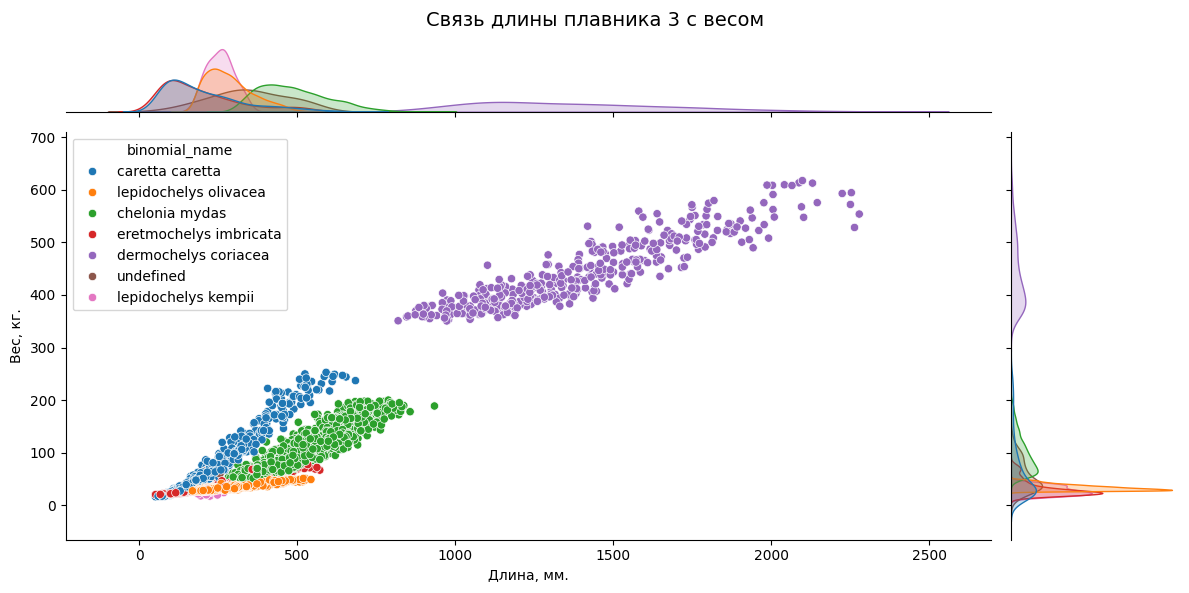

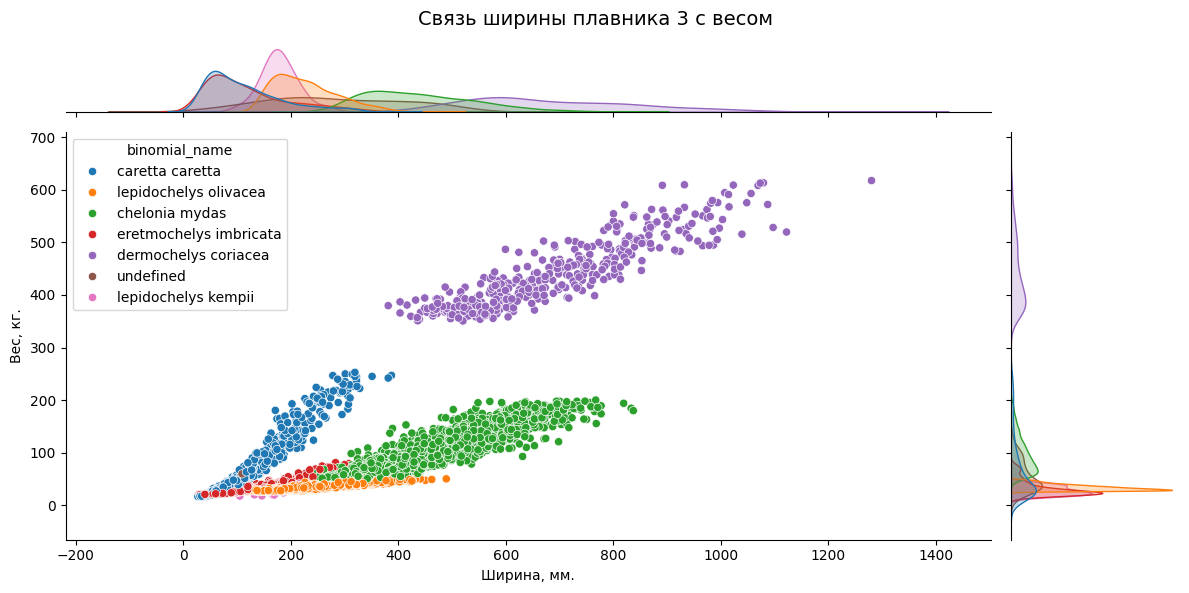

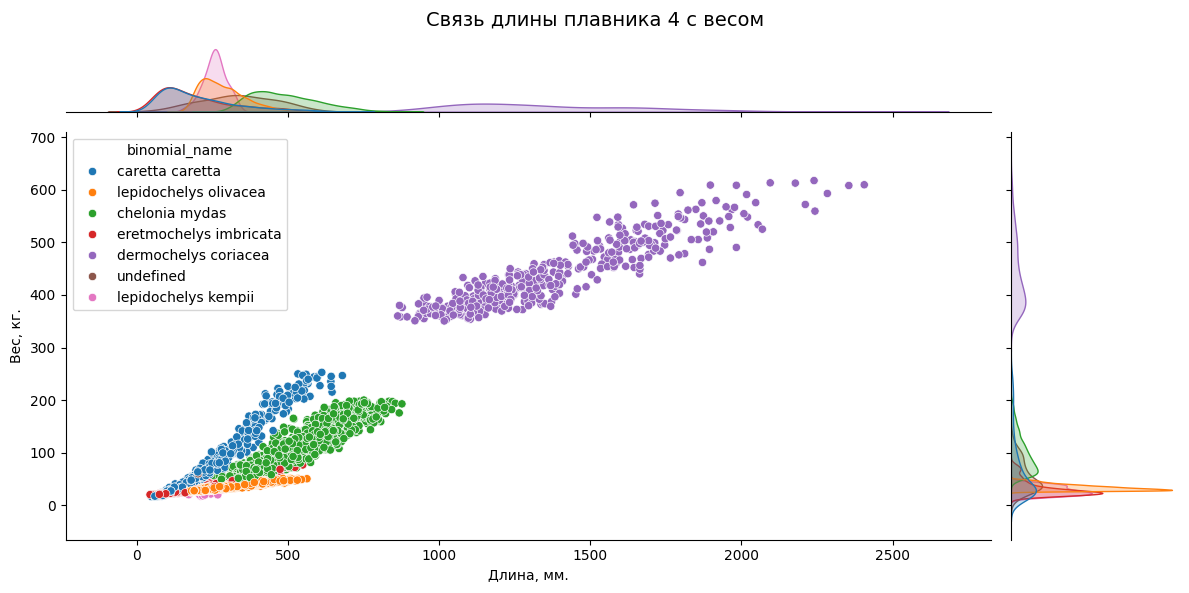

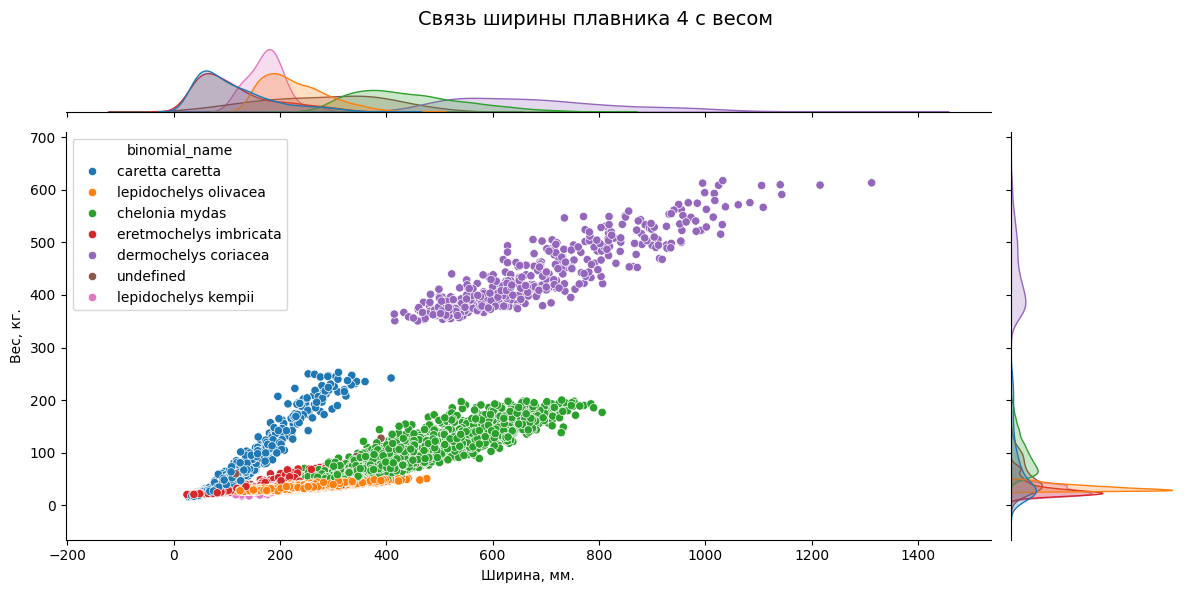

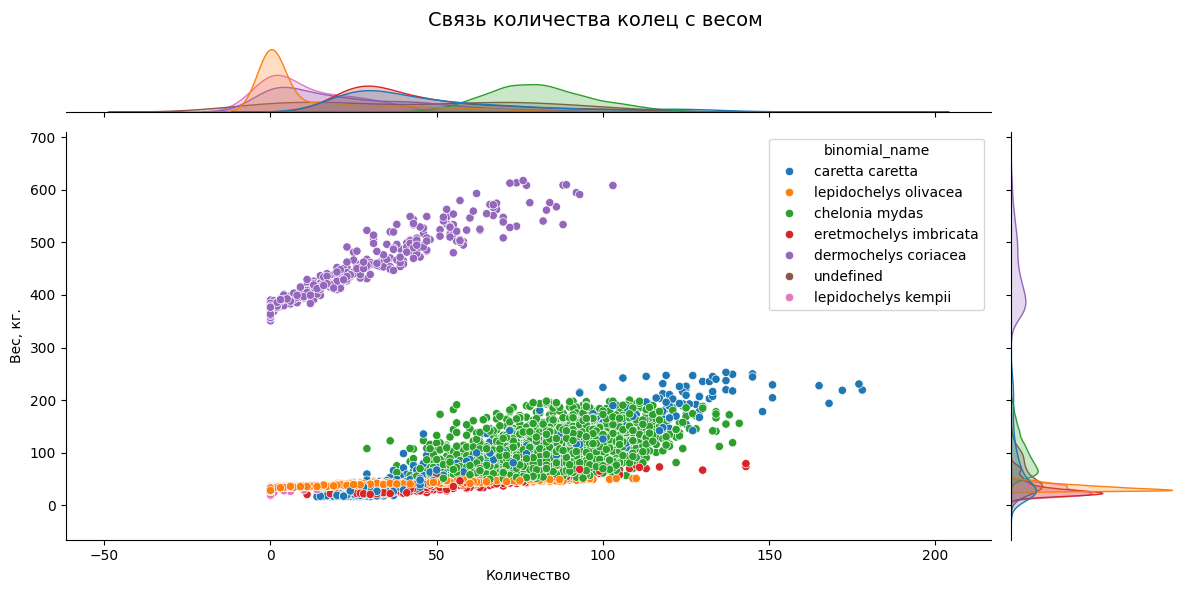

In [17]:
graph_data = [["Связь длины панциря с весом", 'shell_length', 'weight', 'binomial_name', "Длина, мм.", "Вес, кг."],
              ["Связь ширины панциря с весом", 'shell_width', 'weight', 'binomial_name', "Ширина, мм.", "Вес, кг."],
              ["Связь длины головы с весом", 'head_length', 'weight', 'binomial_name', "Длина, мм.", "Вес, кг."],
              ["Связь ширины головы с весом", 'head_width', 'weight', 'binomial_name', "Ширина, мм.", "Вес, кг."],
              ["Связь длины плавника 1 с весом", 'flipper_length_1', 'weight', 'binomial_name', "Длина, мм.", "Вес, кг."],
              ["Связь ширины плавника 1 с весом", 'flipper_width_1', 'weight', 'binomial_name', "Ширина, мм.", "Вес, кг."],
              ["Связь длины плавника 2 с весом", 'flipper_length_2', 'weight', 'binomial_name', "Длина, мм.", "Вес, кг."],
              ["Связь ширины плавника 2 с весом", 'flipper_width_2', 'weight', 'binomial_name', "Ширина, мм.", "Вес, кг."],
              ["Связь длины плавника 3 с весом", 'flipper_length_3', 'weight', 'binomial_name', "Длина, мм.", "Вес, кг."],
              ["Связь ширины плавника 3 с весом", 'flipper_width_3', 'weight', 'binomial_name', "Ширина, мм.", "Вес, кг."],
              ["Связь длины плавника 4 с весом", 'flipper_length_4', 'weight', 'binomial_name', "Длина, мм.", "Вес, кг."],
              ["Связь ширины плавника 4 с весом", 'flipper_width_4', 'weight', 'binomial_name', "Ширина, мм.", "Вес, кг."],
              ["Связь количества колец с весом", 'circle_count', 'weight', 'binomial_name', "Количество", "Вес, кг."]]

for kwargs in graph_data:
    draw_jointplot(df, *kwargs)

Зависимость веса от измерений имеет разный характер для разных видов. Поэтому сведения о виде черепахи необходимо использовать при обучении модели, а строки с пропусками в столбце `binomial_name` (были помечены как `undefined`) стоит удалить:

In [18]:
undefined_count = len(df[df['binomial_name'] == 'undefined'])

print(f"Количество пропусков в binomial_name: {undefined_count}")
df = df[df['binomial_name'] != 'undefined']
print(f"Новое количество строк в датасете: {len(df)}")

Количество пропусков в binomial_name: 42
Новое количество строк в датасете: 7477


**Выводы:** 
- Как и предполагалось, выбросы связаны с видовыми отличиями: более крупные черепахи видов `dermochelys coriacea` и `chelonia mydas` имеют большие значения измерений, которые на общей диаграмме попадают в выбросы. Датасет не содержит аномальных значений. 
- Зависимость веса от измерений близка к линейной, но имеет разные параметры для разных видов.

### 2.4. Исследование корреляции веса с параметрами измерений.

- Построим тепловую карту корреляции Пирсона для веса и числовых параметров:

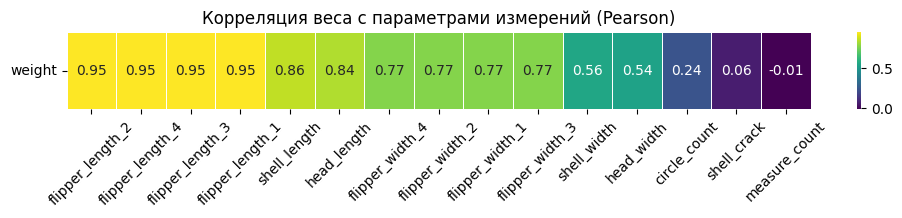

In [19]:
corr_cols = int_cols.copy()
corr_cols.append('weight')
s_corr = pd.DataFrame(df[corr_cols].corr(numeric_only=True)['weight'].drop('weight').sort_values(ascending=False)).T
draw_heatmap(s_corr, "Корреляция веса с параметрами измерений (Pearson)")

Видна сильная линейная корреляция веса с длиной ласт, панциря и головы. Немного слабее корреляция с их шириной, самая слабая - с количеством колец. Корреляция с количеством трещин и измерений отсутствует.

**Выводы**:
- Были обнаружены и удалены записи с нулевым весом в количестве 8 шт. Новое количество строк в датасете - 7519.
- Распределение и диапазон значений для измеренных параметров соответствуют характерным значениям для перечисленных видов черепах. Более крупные виды, такие как `dermochelys coriacea` и `chelonia mydas` демонстрируют большие значения измерений и веса, которые на общей диаграмме попадали в выбросы.
- Зависимость веса черепах от измерений близка к линейной с разным количеством отклонений: наименьшее отклонение от линейной зависимости - у параметров панциря, больший разброс значений - у параметров головы и ласт. Наибольший разброс - у количества колец.
- На диаграммах также виден разный характер зависимости веса от измерений для разных видов черепах: для `lepidochelys olivacea` зависимость везде очень близка к строго линейной. Для `dermochelys coriacea`, `chelonia mydas` и `caretta caretta` линейная зависимость размывается большим разбросом значений. Также на некоторых диаграммах можно заметить ускорение роста веса при росте параметров (например, для видов `caretta caretta` и `dermochelys coriacea`). Вероятно, для этих видов лучший по сравнению с линейной результат дала бы полиномиальная регрессия со степенью 2. Во всяком случае, поскольку зависимость веса от измерений отличается для разных видов, категория вида должна учитываться при обучении модели.
- Корреляция Пирсона показывает сильную линейную зависимость веса от длины ласт, панциря и головы. Немного слабее корреляция с их шириной, самая слабая - с количеством колец. Корреляция с количеством трещин и измерений отсутствует. Последние два параметра можно исключить из обучения модели.

## 3. Подготовка данных для машинного обучения.
Сначала необходимо определить набор признаков, которые будут использоваться при обучении модели. 
- На этапе исследовательского анализа было установлено, что зависимость веса от измерений имеет разный характер для разных видов. По этой причине информация о виде должна быть включена в данные для обучения. Для кодирования неупорядоченных категориальных данных с небольшим количеством значений предлагается использовать метод one-hot encoding.
- Столбцы `shell_crack` и `measure_count` не влияют на вес, поэтому их можно исключить из обучающего датасета.

In [20]:
# Формируем данные для модели
ml_cols = ['shell_length',
           'shell_width',
           'head_length',
           'head_width',
           'flipper_length_1',
           'flipper_width_1',
           'flipper_length_2',
           'flipper_width_2',
           'flipper_length_3',
           'flipper_width_3',
           'flipper_length_4',
           'flipper_width_4',
           'circle_count',
           'binomial_name',
           'weight']

# Добавляем one-hot признаки для видов черепах
df_learn = pd.get_dummies(df[ml_cols], columns=['binomial_name'], drop_first=True, dtype=int)
#df_learn = df[ml_cols]
display(df_learn.head(10))

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight,binomial_name_chelonia mydas,binomial_name_dermochelys coriacea,binomial_name_eretmochelys imbricata,binomial_name_lepidochelys kempii,binomial_name_lepidochelys olivacea
0,700,381,112,82,356,205,331,185,270,180,273,144,63,87.686996,0,0,0,0,0
1,341,295,65,48,216,190,229,186,164,182,180,149,0,26.948999,0,0,0,0,1
2,408,343,71,70,308,224,285,232,264,179,268,176,0,30.016001,0,0,0,0,1
4,408,307,50,54,280,168,269,218,199,165,209,180,0,28.511000,0,0,0,0,1
5,341,254,54,55,250,204,240,217,197,152,185,154,0,27.513000,0,0,0,0,1
6,606,526,114,91,489,407,460,316,440,260,326,300,32,40.228001,0,0,0,0,1
7,600,551,104,109,411,328,396,338,356,258,321,266,20,38.838001,0,0,0,0,1
8,742,652,118,147,411,386,507,389,414,368,311,325,66,56.352001,1,0,0,0,0
10,157,85,27,21,82,43,77,40,61,38,66,37,21,20.555000,0,0,1,0,0
11,1336,1318,207,248,845,704,661,768,587,686,661,585,111,154.074005,1,0,0,0,0


- Разделим датасет на обучающую, валидационную и тестовую выборки в отношении 60%/20%/20%:

In [21]:
y = df_learn['weight']
X = df_learn.drop('weight', axis=1)

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42, shuffle=True)

print(f"Размеры выборок: \n\tобучающая: {len(X_train)}; \n\tвалидационная: {len(X_val)}; \n\tтестовая: {len(X_test)}.")

Размеры выборок: 
	обучающая: 4485; 
	валидационная: 1496; 
	тестовая: 1496.


- Масштабируем выборки с использованием стандартизации:

In [22]:
def scale_data(X_train, X_val, X_test, method='standard'):
    if method == 'standard':
        mean = X_train.mean()
        std = X_train.std()
        X_train_scaled = (X_train - mean) / std
        X_val_scaled = (X_val - mean) / std
        X_test_scaled = (X_test - mean ) / std
    elif method == 'minmax':
        min_val = X_train.min()
        max_val = X_train.max()
        X_train_scaled = (X_train - min_val) / (max_val - min_val)
        X_val_scaled = (X_val - min_val) / (max_val - min_val)
        X_test_scaled = (X_test - min_val) / (max_val - min_val)
    else:
        raise ValueError("Неверный метод масштабирования. Используйте 'standard' или 'minmax'.")
    return X_train_scaled, X_val_scaled, X_test_scaled

X_train_scaled, X_val_scaled, X_test_scaled = scale_data(X_train, X_val, X_test)

## 4. Обучение линейных моделей.

- Описание необходимых функций:

In [23]:
def run_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = math.sqrt(mean_squared_error(y_test, y_test_pred))
    mae = mean_absolute_error(y_test, y_test_pred)
    mape = mean_absolute_percentage_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)
    return y_test_pred, mse, rmse, mae, mape, r2

- Сначала обучим и оценим модель `LinearRegression` (решение, связанное с обращением матрицы признаков):

In [24]:
print(run_model(LinearRegression(), X_train_scaled, y_train, X_test_scaled, y_test))
print(run_model(LinearRegression(), X_train_scaled, y_train, X_val_scaled, y_val))
print(run_model(SGDRegressor(), X_train_scaled, y_train, X_test_scaled, y_test))
print(run_model(SGDRegressor(), X_train_scaled, y_train, X_val_scaled, y_val))
print(run_model(SGDRegressor(loss='squared_epsilon_insensitive', epsilon=0), X_train_scaled, y_train, X_test_scaled, y_test))
print(run_model(SGDRegressor(loss='huber'), X_train_scaled, y_train, X_test_scaled, y_test))
print(run_model(Ridge(alpha=0.001), X_train_scaled, y_train, X_test_scaled, y_test))
print(run_model(Ridge(alpha=0.01), X_train_scaled, y_train, X_test_scaled, y_test))
print(run_model(Ridge(alpha=1), X_train_scaled, y_train, X_test_scaled, y_test))
print(run_model(Ridge(alpha=10), X_train_scaled, y_train, X_test_scaled, y_test))
print(run_model(Lasso(alpha=0.01), X_train_scaled, y_train, X_test_scaled, y_test))
print(run_model(Lasso(alpha=0.1), X_train_scaled, y_train, X_test_scaled, y_test))
print(run_model(Lasso(alpha=1), X_train_scaled, y_train, X_test_scaled, y_test))
print(run_model(Lasso(alpha=10), X_train_scaled, y_train, X_test_scaled, y_test))


(array([ 37.08011561, 112.62572106,  34.21016077, ...,  29.37107327,
       113.05905449,  80.47245522], shape=(1496,)), 124.93095566642289, 11.177251704530184, 8.185134008092115, 0.186660690095164, 0.9854837875032078)
(array([ 70.14130973,  59.74870116, 128.87991843, ...,  17.11283918,
        18.43963268,  25.8091423 ], shape=(1496,)), 133.96652165072567, 11.57439076801564, 8.42377263512253, 0.19456987953171956, 0.9855765536979669)
(array([ 36.06479045, 114.13274015,  34.34882513, ...,  29.30527951,
       112.67129751,  80.0218957 ], shape=(1496,)), 127.80302595586649, 11.305000042276271, 8.28837752731542, 0.19294038600279648, 0.9851500705120514)
(array([ 69.33998929,  60.7160681 , 129.91700944, ...,  16.44589206,
        18.10348312,  25.43275789], shape=(1496,)), 135.06341010201248, 11.621678454595639, 8.484883755537183, 0.19782011771364807, 0.9854584576879973)
(array([ 36.23729766, 114.40893588,  34.2066703 , ...,  29.14055871,
       113.59628705,  80.67209437], shape=(1496,)), 

c:\Users\TEXNH MAKPH\Projects\Yandex DS\ds-yandex\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:1612: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [25]:
model_sgdreg = SGDRegressor()
model_sgdreg.fit(X_train_scaled, y_train)

y_train_pred_sgd = model_sgdreg.predict(X_train_scaled)
print(mean_squared_error(y_train, y_train_pred_sgd))
print(mean_absolute_error(y_train, y_train_pred_sgd))
print(mean_absolute_percentage_error(y_train, y_train_pred_sgd))
print(r2_score(y_train, y_train_pred_sgd))

y_test_pred_sgd = model_sgdreg.predict(X_test_scaled)
print(mean_squared_error(y_test, y_test_pred_sgd))
print(mean_absolute_error(y_test, y_test_pred_sgd))
print(mean_absolute_percentage_error(y_test, y_test_pred_sgd))
print(r2_score(y_test, y_test_pred_sgd))

147.78354907169125
8.74739936802673
0.1946253174391186
0.9840303788728507
127.499668651541
8.235394022498198
0.18878485323432628
0.98518531877433
